# Exploratory Data Analysis

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import string
import re
from itertools import combinations
from collections import Counter, defaultdict
from typing import Dict, List
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from tqdm import tqdm
import spacy
from sklearn.feature_extraction.text import CountVectorizer

from vtt.data.caption_preprocessing import (
    load_and_clean_captions, 
    build_raw_captions_dict_from_csv
)
from vtt.evaluation.metrics import (
    compute_bleu_scores,
    compute_meteor_scores,
    compute_bertscore,
)

/opt/anaconda3/envs/genai_project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Output Directory

In [7]:
output_dir = "../outputs/figures/eda_30k"

## Image EDA

### Image Directory Path

In [3]:
image_folder = "../data/raw/flickr30k_images/Images"

### Dimension Analysis

In [4]:
widths, heights = [], []
for filename in tqdm(os.listdir(image_folder), desc="Processing images dimensions"):
    if filename.endswith((".jpg", ".jpeg", ".png")):
        with Image.open(os.path.join(image_folder, filename)) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

Processing images dimensions: 100%|██████████| 31783/31783 [00:06<00:00, 4675.33it/s]


#### Distribution of Heights and Widths

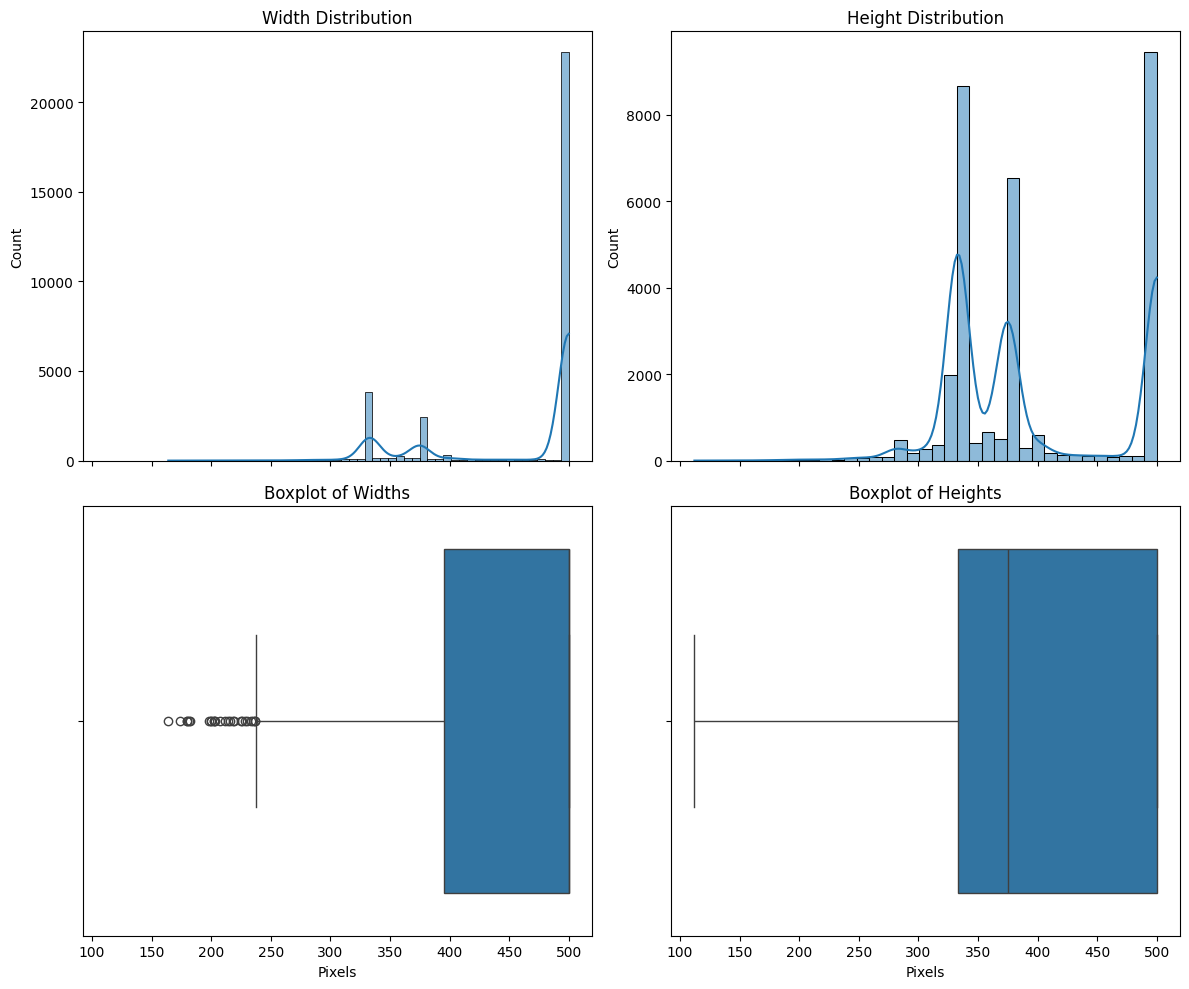

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

sns.histplot(widths, kde=True, ax=axs[0, 0])
axs[0, 0].set_title("Width Distribution")

sns.histplot(heights, kde=True, ax=axs[0, 1])
axs[0, 1].set_title("Height Distribution")

sns.boxplot(x=widths, ax=axs[1, 0])
axs[1, 0].set_title("Boxplot of Widths")
axs[1, 0].set_xlabel("Pixels")

sns.boxplot(x=heights, ax=axs[1, 1])
axs[1, 1].set_title("Boxplot of Heights")
axs[1, 1].set_xlabel("Pixels")

fig.savefig(os.path.join(output_dir, "eda30k__image_dimension_distributions.png"))
plt.tight_layout()
plt.show()

#### Summary Stats

In [20]:
print("Width Stats:\n\t",
      f"Min: {np.min(widths)}, Max: {np.max(widths)}, Mean: {np.mean(widths)}")
print("Height Stats:\n\t",
      f"Min: {np.min(heights)}, Max: {np.max(heights)}, Mean: {np.mean(heights)}")

Width Stats:
	 Min: 164, Max: 500, Mean: 459.6071484756002
Height Stats:
	 Min: 112, Max: 500, Mean: 395.13148538526883


#### Interpretation

Widths: 
* There are multiple prominent peaks, indicating that the images come in several standard width sizes (e.g., around 250, 350, and a very high concentration near 500 pixels).

* The distribution is skewed to the right with a long tail on the lower end, but most widths are concentrated near 500 pixels.

* A very large number of images have width close to 500 pixels, possibly indicating resizing or standardization.

Heights: 
* Clear peaks suggest standard heights like ~350 and ~500 pixels.

* While still right-skewed, it’s slightly more evenly spread than the width distribution.

*  Around 500 pixels, again indicating standardizat

Summary:
* The height has a broader spread compared to width, with a lower average and wider IQR.

* The histogram shows distinct peaks — likely from common image sizes — but more spread out than width.

* Fewer outliers are visible, but the greater range (112–500 px) means height normalization might be more critical.

### Aspect Ratio Analysis

In [21]:
aspect_ratios = [w / h for w, h in zip(widths, heights)]

#### Distribution of the Aspect Ratios

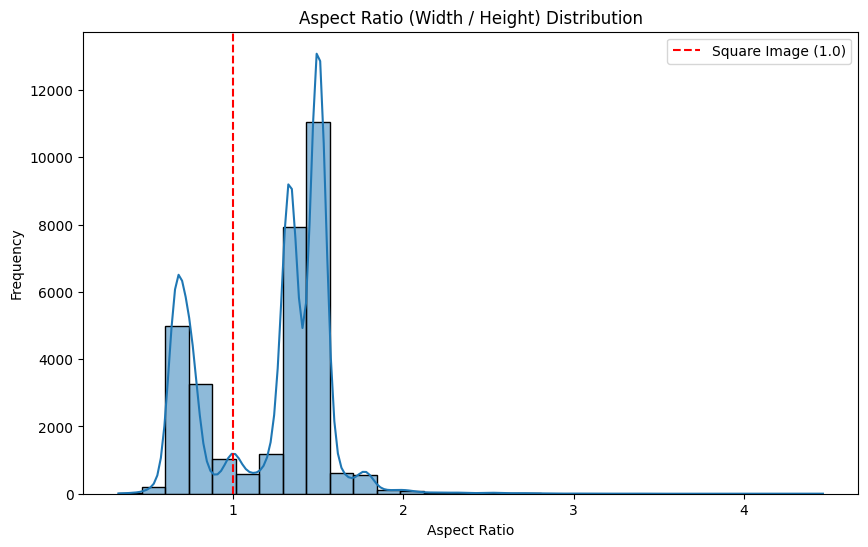

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(aspect_ratios, bins=30, kde=True, ax=ax)
ax.set_title("Aspect Ratio (Width / Height) Distribution")
ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Frequency")
ax.axvline(x=1.0, color='r', linestyle='--', label='Square Image (1.0)')

fig.savefig(os.path.join(output_dir, "eda30k_image_aspect_ratio_distribution.png"))
plt.legend()
plt.show()

#### Interpretation

Observations:
* The histogram and KDE curve show several distinct peaks, indicating multiple dominant aspect ratios, likely due to different source formats or capture settings.

* The largest cluster lies between 1.3 and 1.6, indicating that many images are landscape-oriented, i.e., wider than tall.

* A smaller cluster is also visible around 0.8 to 1.0, showing the presence of portrait-oriented images.



### Color Analysis

#### Color Distribution

In [23]:
r_hist, g_hist, b_hist = np.zeros(256), np.zeros(256), np.zeros(256)
n_images = 0

for filename in tqdm(os.listdir(image_folder), desc="Processing image colors..."):
    if filename.endswith((".jpg", ".jpeg", ".png")):
        with Image.open(os.path.join(image_folder, filename)) as img:
            img = img.convert("RGB")
            r, g, b = img.split()
            r_hist += np.array(r.histogram())
            g_hist += np.array(g.histogram())
            b_hist += np.array(b.histogram())
            n_images += 1

# Normalize
r_hist /= n_images
g_hist /= n_images
b_hist /= n_images

Processing image colors...: 100%|██████████| 31783/31783 [01:21<00:00, 388.17it/s]


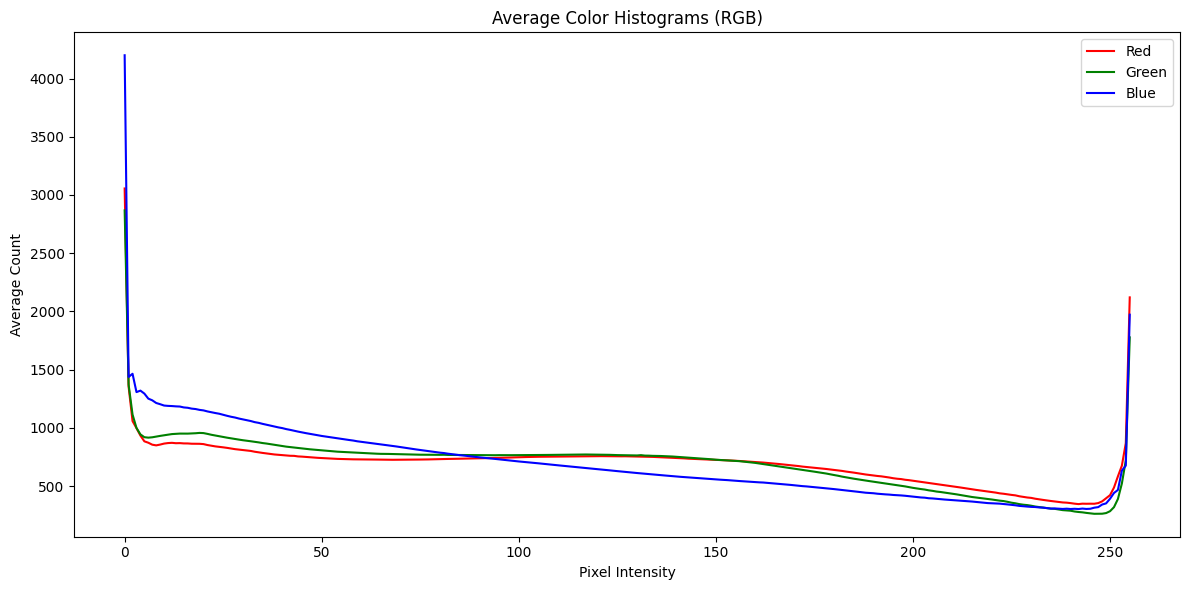

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(r_hist, color='red', label='Red')
ax.plot(g_hist, color='green', label='Green')
ax.plot(b_hist, color='blue', label='Blue')
ax.set_title("Average Color Histograms (RGB)")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Average Count")
ax.legend()
fig.savefig(os.path.join(output_dir, "eda30k_image_color_distribution.png"))
plt.tight_layout()
plt.show()

#### Interpretation

Observations:
* All three channels show sharp peaks at 0 (black) and 255 (white).

* The midrange (50–200) has comparatively lower frequency, indicating that moderate pixel intensities are less common.

* The blue line is higher than red and green for low intensities (0–50), suggesting that dark blue or bluish tones are more common in shadows or dark regions of the dataset.

* All curves fall off steadily toward the mid-intensities and slightly rise again near 255, reinforcing the idea that images contain both extreme low and high intensity values.


## Caption Analysis

### Caption File Path

In [26]:
captions_file = "../data/raw/flickr30k_captions.csv"

### Captions per Image

In [28]:
# Load CSV
#df = pd.read_csv(captions_file)
df = pd.read_csv(captions_file, on_bad_lines='skip')  # For pandas ≥ 1.3.0


# Count captions per image
caption_counts = df['image'].value_counts()

# Check basic stats
print("Unique images:", df['image'].nunique())
print("Total captions:", len(df))
print("Average captions per image:", caption_counts.mean())

# Identify any anomalies
print(f"\nList of Images with < 5 captions:\n\t{caption_counts[caption_counts < 5]}")
print(f"\nList of Images with > 5 captions:\n\t{caption_counts[caption_counts > 5]}")

Unique images: 31783
Total captions: 157624
Average captions per image: 4.9593808010571685

List of Images with < 5 captions:
	image
264928854.jpg     4
8190802361.jpg    4
2705920066.jpg    4
353180303.jpg     4
4772268645.jpg    4
                 ..
3687996569.jpg    3
2099852435.jpg    3
3154107557.jpg    2
1150429218.jpg    2
191652362.jpg     2
Name: count, Length: 1254, dtype: int64

List of Images with > 5 captions:
	Series([], Name: count, dtype: int64)


#### Interpretation

* The Flickr30k dataset contains 31,783 unique images and 157,624 captions, yielding an average of approximately 4.96 captions per image. While the dataset is designed to provide five captions per image, the analysis reveals annotation inconsistencies:

* 1,254 images have fewer than 5 captions

* Some images have as few as 2 captions

* No images have more than 5 captions

In [31]:
print(df.columns)


Index(['image', ' caption'], dtype='object')


### Caption Length Distribution

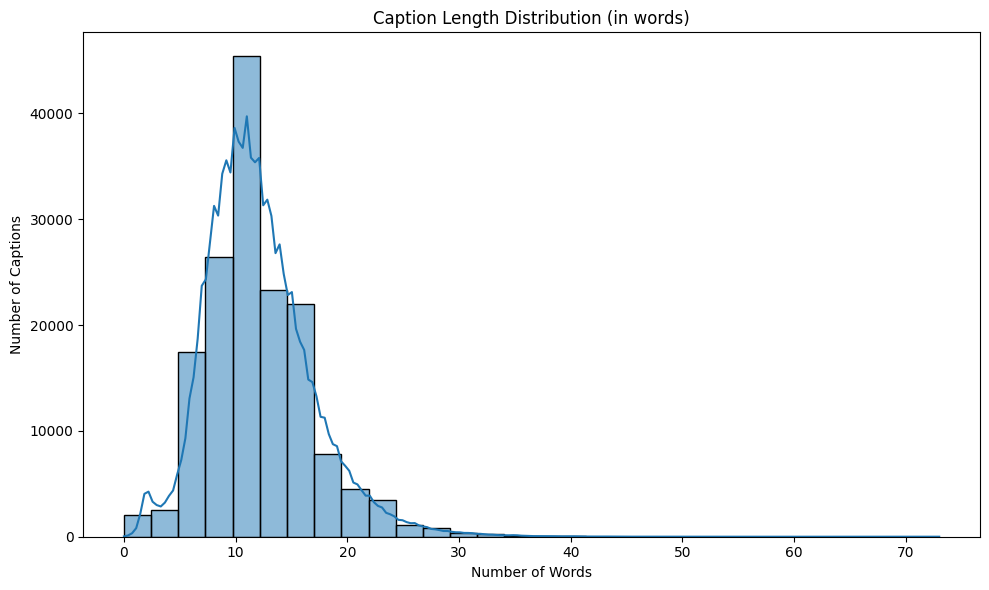

Summary Stats
Min length: 0
Max length: 73
Mean length: 12.069615033243668
Median length: 11.0


In [32]:
# Add a column for caption length (in words)
df['caption_len'] = df[' caption'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['caption_len'], bins=30, kde=True)
ax.set_title("Caption Length Distribution (in words)")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Number of Captions")
fig.savefig(os.path.join(output_dir, "eda30k_caption_length_distribution.png"))
plt.tight_layout()
plt.show()

# Stats
print("Summary Stats")
print(f"Min length: {df['caption_len'].min()}")
print(f"Max length: {df['caption_len'].max()}")
print(f"Mean length: {df['caption_len'].mean()}")
print(f"Median length: {df['caption_len'].median()}")

#### Interpretation

* The distribution of caption lengths follows a right-skewed pattern, centered around 10–12 words, with a long tail extending to over 70 words.
Peak frequency occurs at around 11 words, aligning with the median.

* The majority of captions (roughly 80–90%) fall within the 8–18 word range.

* There are a few very short captions (fewer than 5 words), and a small number of extremely long captions (30+ words), which contribute to the right-skew.

* The KDE curve (blue line) further confirms that caption lengths are not normally distributed but instead cluster around a lower range with rare outliers.



### Vocab & Word Frequencies

Vocabulary size: 19167


/var/folders/04/hj7m_hs56ls5zqfdq0x332kc0000gn/T/ipykernel_2682/424103880.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45) #, ha='right')


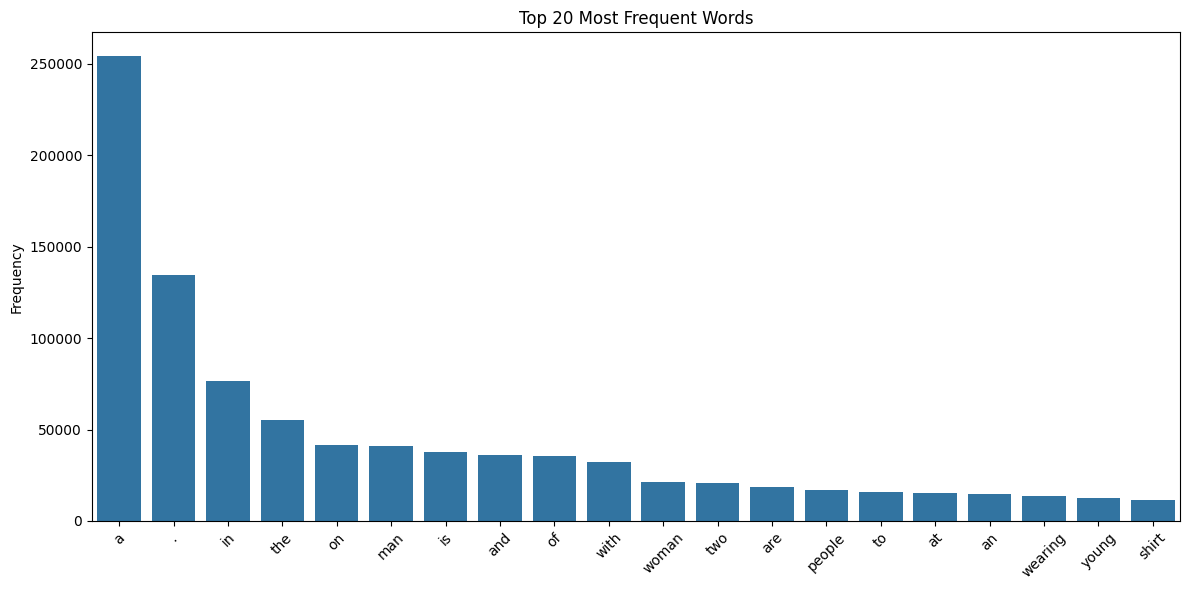

In [34]:
# Tokenize captions into words
all_words = []
for caption in df[' caption']:
    all_words.extend(str(caption).lower().split())

# Count frequency
word_freq = Counter(all_words)

# Vocabulary size
vocab_size = len(word_freq)
print("Vocabulary size:", vocab_size)

# Top 20 frequent words
common_words = word_freq.most_common(20)

# Plot
words, freqs = zip(*common_words)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=list(words), y=list(freqs), ax=ax)
ax.set_title("Top 20 Most Frequent Words")
ax.set_ylabel("Frequency")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45) #, ha='right')
fig.savefig(os.path.join(output_dir, "eda30k_most_frequent_words.png"))
plt.tight_layout()
plt.show()

#### Interpretation

Observations
* The top word is "a", followed by punctuation ".", and common prepositions like "in," "on," "of," "with," and "at."These words reflect the typical syntactic structure of captions, which often begin with a determiner (“a man,” “a woman”) and describe spatial relations or activities.

* "man," "woman," "people," "shirt," "young," and "wearing" highlight the dataset’s strong focus on people-centric and clothing-related descriptions.

#### Rare Words Analysis

In [35]:
# Rare words threshold (e.g., words that occur once or twice)
rare_thresh = 1
rare_words = [word for word, count in word_freq.items() if count <= rare_thresh]

print("Rare words (≤ 1 occurrence):", len(rare_words))
print("Percentage of rare words in vocab:", len(rare_words) / vocab_size * 100)

Rare words (≤ 1 occurrence): 7340
Percentage of rare words in vocab: 38.29498617415349


#### Interpretation

Rare Words:
* 7340 words occur only once, making up ~38% of the vocabulary.



### POS Tagging Distribution

### N-gram Analysis

/var/folders/04/hj7m_hs56ls5zqfdq0x332kc0000gn/T/ipykernel_2682/1076355278.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45) #, ha='right')


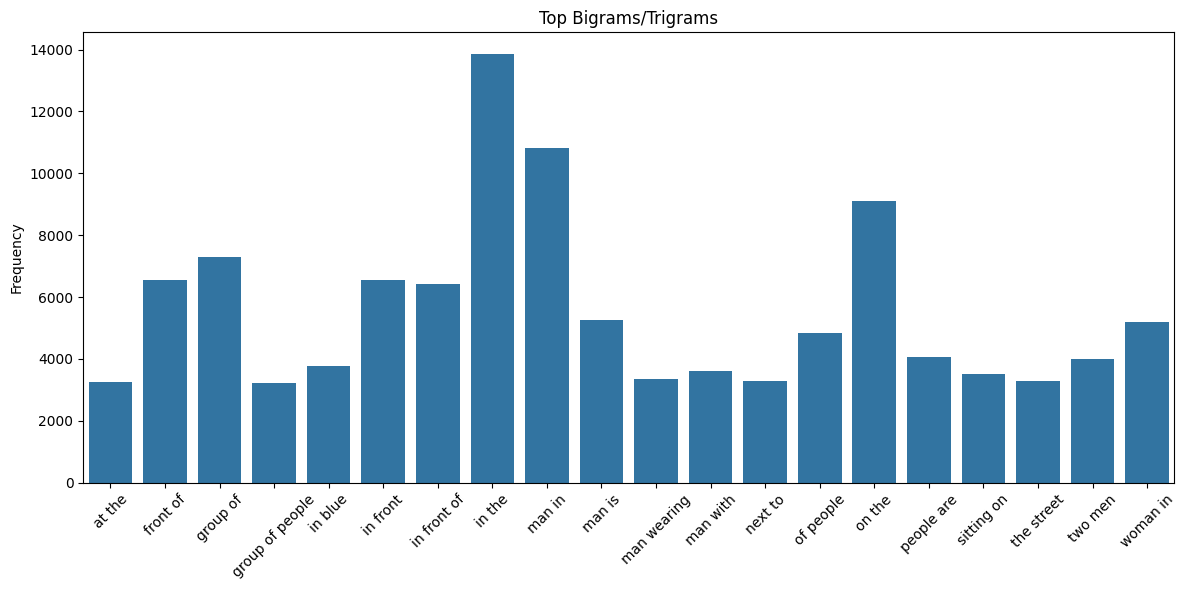

In [36]:
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=20)
X = vectorizer.fit_transform(df[' caption'].astype(str))
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=ngrams, y=counts, ax=ax)
ax.set_title("Top Bigrams/Trigrams")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45) #, ha='right')
ax.set_ylabel("Frequency")
fig.savefig(os.path.join(output_dir, "eda_top_ngrams.png"))
plt.tight_layout()
plt.show()

#### Interpretation

Observations:
* Phrases like "in front of", "on the", "at the", and "next to" occur frequently. This highlights that captions often describe the position and relationships between people or objects in the scene.

* Phrases such as "man in," "man is," "man wearing," "two men," "woman in," "group of people," "people are" reflect the dataset's emphasis on human subjects and their actions.

* Phrases like "in blue" and "man wearing" indicate that attire and color are common visual details included in descriptions.

### Punctuation & Special Characters

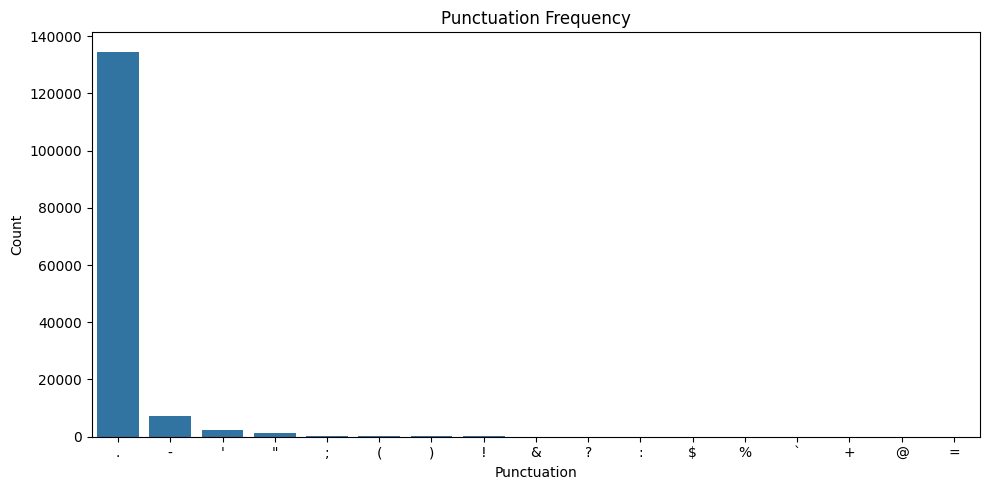

In [39]:
punct_count = Counter()
for caption in df[' caption']:
    puncts = re.findall(f"[{re.escape(string.punctuation)}]", str(caption))
    punct_count.update(puncts)

# Plot
puncts, p_counts = zip(*punct_count.most_common())
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=list(puncts), y=list(p_counts))
ax.set_title("Punctuation Frequency")
ax.set_xlabel("Punctuation")
ax.set_ylabel("Count")
#fig.savefig("../figures/eda_30k_eda30k_puncation_frequency.png")
fig.savefig(os.path.join(output_dir, "eda30k_punctuation_frequency.png"))
plt.tight_layout()
plt.show()

#### Interpretation

Observations:
* The period "." appears overwhelmingly more frequently than any other mark — over 130,000 times, indicating that the vast majority of captions are written as complete sentences.

* Dashes (-), apostrophes ('), and quotation marks (") occur occasionally

* Marks like exclamation points (!), question marks (?), and symbols ($, &, @) are extremely rare or nearly absent.



## Summary

| **Aspect**               | **Observation**                               | **Implication for Generalization**                                                          |
| ------------------------ | --------------------------------------------- | ------------------------------------------------------------------------ |
| **Images**               |                                               |                                                                          |
| Unique images            | 31783                                         | Provides a large and diverse evaluation set beyond Flickr8k           |
| Captions per image       | ~4.96                                     | Slight caption inconsistency may affect metrics like BLEU    |
| Images with < 5 captions | 1,254 images (2–4 captions)                                          | Some images have fewer references, reducing evaluation robustness                                               |
| Images with > 5 captions | None                                          | No over-annotation; structure is mostly predictable                                             |
|                          |                                               |                                                                          |
| **Captions**             |                                               |                                                                          |
| Total captions           | 157,624                                        | Rich captioning content for comprehensive generalization assessment                                 |
| Avg. caption length      | 12.07 words                                   | Captions are concise, useful for training compact language models        |
| Min / Max caption length | 0 / 73 words                                  | Wide variance — longer outliers may challenge n-gram based evaluation               |
| Median caption length    | 11 words                                      | Similar to Flickr8k — supports meaningful comparison               |
| Most frequent words      | 	"a", ".", "in", "the", "man", "on", "is"                | Retains syntactic consistency, but content words differ from Flickr8k              |
| Common n-grams           | "in the", "group of people", "man is"     | More complex and people-centric patterns than Flickr8k                     |
| Punctuation use          | Mostly periods (.); other marks rare                          | Declarative sentence style aligns well with Flickr8k                                    |
| Rare words               | 7,340 words (38.3% of vocab) occur only once | Suggests some variability in preprocessing; case may influence evaluation |
